<a href="https://colab.research.google.com/github/bagchiarindam2022/chest-xray-image-processing-using-cnn/blob/main/Final_Year_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Update DATASET_DIR
DATASET_DIR = os.path.join(path, "chest_xray")

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [ ]:

# Import the os module for interacting with the operating system, like joining paths.
import os
# Import the core PyTorch library for tensor operations and neural networks.
import torch
# Import the neural network module from PyTorch.
import torch.nn as nn
# Import the optimization module from PyTorch, which contains various optimization algorithms.
import torch.optim as optim
# Import the functional module from PyTorch, providing activation functions, pooling operations, etc.
import torch.nn.functional as F
# Import datasets and transforms from torchvision for image data handling.
from torchvision import datasets, transforms
# Import DataLoader for efficient batching and loading of data.
from torch.utils.data import DataLoader, random_split
# Import PIL (Pillow) for image processing.
from PIL import Image
# Import matplotlib for plotting, specifically for displaying images and confusion matrices.
import matplotlib.pyplot as plt
# Import confusion_matrix and ConfusionMatrixDisplay from sklearn for evaluating classification models.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Import numpy for numerical operations, especially for array manipulation.
import numpy as np

# Update DATASET_DIR: This line constructs the full path to the 'chest_xray' directory
# within the downloaded dataset. The 'path' variable comes from the previous cell's download.
DATASET_DIR = os.path.join(path, "chest_xray")

# Define a series of transformations for the training dataset (train_transform).
# These transformations help in augmenting the data and standardizing it for the model.
train_transform = transforms.Compose([
    # Resize all images to 224x224 pixels. This is a common input size for CNNs.
    transforms.Resize((224, 224)),
    # Randomly flip the image horizontally. This helps the model generalize better.
    transforms.RandomHorizontalFlip(),
    # Randomly rotate the image by up to 10 degrees. Another augmentation technique.
    transforms.RandomRotation(10),
    # Randomly change the brightness and contrast of the image. Further augmentation.
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    # Convert the PIL image (or numpy array) to a PyTorch tensor.
    transforms.ToTensor(),
    # Normalize the tensor with a mean of 0.5 and standard deviation of 0.5 for each channel (RGB).
    # This scales pixel values to the range [-1, 1], which can improve model training.
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Define a series of transformations for the validation and test datasets (val_test_transform).
# These are typically simpler as they don't involve data augmentation, only standardization.
val_test_transform = transforms.Compose([
    # Resize all images to 224x224 pixels, matching the training data input size.
    transforms.Resize((224, 224)),
    # Convert the PIL image to a PyTorch tensor.
    transforms.ToTensor(),
    # Normalize the tensor with the same mean and standard deviation as the training data.
    transforms.Normalize([0.5]*3, [0.5]*3)
])

### **Data Download and Setup**

This first cell is responsible for downloading the required dataset from Kaggle Hub.

In [ ]:

# Import the kagglehub library, which is used to interact with Kaggle datasets.
import kagglehub

# Download the latest version of the 'paultimothymooney/chest-xray-pneumonia' dataset.
# The function returns the local file path where the dataset is downloaded and extracted.
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

# Print the local path to confirm where the dataset files are located.
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
full_dataset = datasets.ImageFolder(os.path.join(DATASET_DIR, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(DATASET_DIR, "train"), transform=val_test_transform)

val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
# print(len(full_dataset))
train_dataset, _ = random_split(full_dataset, [train_size, val_size])
_, val_dataset = random_split(val_dataset, [train_size, val_size])


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ChestXRayCNN(nn.Module):
    def __init__(self):
        super(ChestXRayCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        # Removed self.conv3 as per task instructions
        self.fc1 = nn.Linear(32 * 56 * 56, 512) # Updated input features for fc1
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        # Removed application of self.conv3 as per task instructions
        x = x.view(-1, 32 * 56 * 56) # Updated tensor flattening for fc1
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the model and move it to the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ChestXRayCNN()
model.to(device)

ChestXRayCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)

In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import kagglehub

# Re-define path and DATASET_DIR, and transforms
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
DATASET_DIR = os.path.join(path, "chest_xray")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

full_dataset = datasets.ImageFolder(os.path.join(DATASET_DIR, "train"), transform=train_transform)
val_dataset_initial = datasets.ImageFolder(os.path.join(DATASET_DIR, "train"), transform=val_test_transform)

val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_dataset, _ = random_split(full_dataset, [train_size, val_size])
_, val_dataset = random_split(val_dataset_initial, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1);
            total += labels.size(0);
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss/len(train_loader):.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch+1}] Complete. Current LR: {optimizer.param_groups[0]['lr']}")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Epoch [1/10], Loss: 0.3339, Val Loss: 0.1420, Val Acc: 94.82%
Epoch [1] Complete. Current LR: 0.001
Epoch [2/10], Loss: 0.1523, Val Loss: 0.1233, Val Acc: 95.40%
Epoch [2] Complete. Current LR: 0.001
Epoch [3/10], Loss: 0.1315, Val Loss: 0.0866, Val Acc: 96.74%
Epoch [3] Complete. Current LR: 0.001


KeyboardInterrupt: 

M

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# -----------------------
# 1. Removed Class Weights (as per user request)
# -----------------------

# -----------------------
# 2. Refined Model, Loss, and Optimizer
# -----------------------
model = ChestXRayCNN().to(device)

# No weights passed to the criterion as per user request
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Added a Scheduler: Reduces LR by half if Val Loss doesn't improve for 2 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# -----------------------
# 3. Refined Training Loop (Excerpt)
# -----------------------
EPOCHS = 10 # Define EPOCHS if not already defined elsewhere, assuming 10 for consistency

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels) # Weights are applied here
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation logic
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss/len(train_loader):.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

    # Update the scheduler based on validation loss
    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch+1}] Complete. Current LR: {optimizer.param_groups[0]['lr']}")

Epoch [1/10], Loss: 0.2667, Val Loss: 0.1172, Val Acc: 95.49%
Epoch [1] Complete. Current LR: 0.001
Epoch [2/10], Loss: 0.1531, Val Loss: 0.1625, Val Acc: 93.67%
Epoch [2] Complete. Current LR: 0.001
Epoch [3/10], Loss: 0.1427, Val Loss: 0.0716, Val Acc: 97.22%
Epoch [3] Complete. Current LR: 0.001
Epoch [4/10], Loss: 0.1207, Val Loss: 0.0700, Val Acc: 97.03%
Epoch [4] Complete. Current LR: 0.001
Epoch [5/10], Loss: 0.0961, Val Loss: 0.0810, Val Acc: 97.60%
Epoch [5] Complete. Current LR: 0.001
Epoch [6/10], Loss: 0.1014, Val Loss: 0.0914, Val Acc: 96.64%
Epoch [6] Complete. Current LR: 0.001
Epoch [7/10], Loss: 0.1038, Val Loss: 0.0935, Val Acc: 96.36%
Epoch [7] Complete. Current LR: 0.0005
Epoch [8/10], Loss: 0.0776, Val Loss: 0.0738, Val Acc: 97.79%
Epoch [8] Complete. Current LR: 0.0005
Epoch [9/10], Loss: 0.0756, Val Loss: 0.0594, Val Acc: 98.37%
Epoch [9] Complete. Current LR: 0.0005
Epoch [10/10], Loss: 0.0657, Val Loss: 0.0498, Val Acc: 98.18%
Epoch [10] Complete. Current LR: 0

In [ ]:
torch.save(model.state_dict(), "chest_xray_model.pth")


In [ ]:
model.load_state_dict(torch.load("chest_xray_model.pth"))
model.eval()



ChestXRayCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)

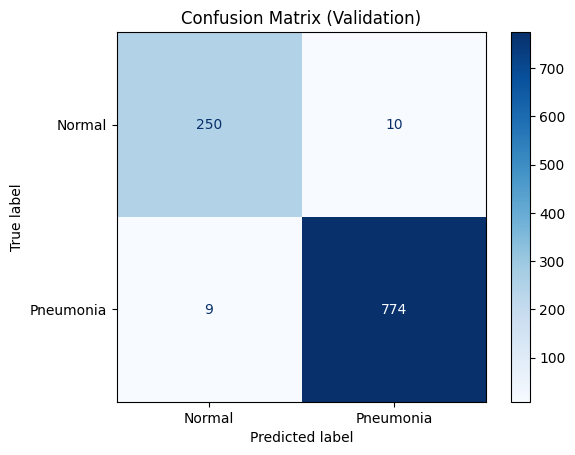

In [ ]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Pneumonia"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation)")
plt.show()


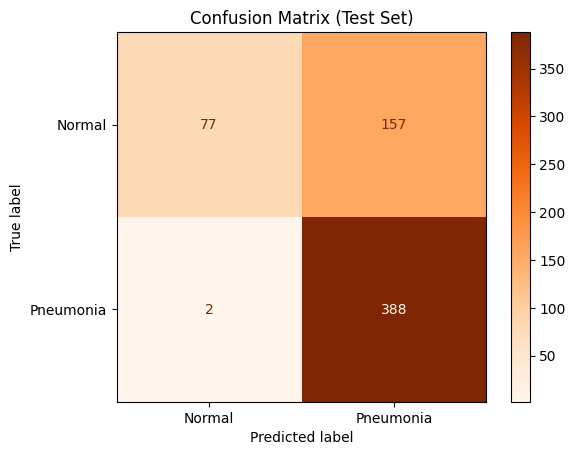

🎯 Test Accuracy: 74.52%


In [ ]:
test_dataset = datasets.ImageFolder(os.path.join(DATASET_DIR, "test"), transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

model.eval()
test_preds, test_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.numpy())

test_cm = confusion_matrix(test_labels, test_preds)
test_disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=["Normal", "Pneumonia"])
test_disp.plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix (Test Set)")
plt.show()

# Accuracy
test_acc = (np.array(test_preds) == np.array(test_labels)).mean()
print(f"🎯 Test Accuracy: {test_acc * 100:.2f}%")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F


In [ ]:
def predict_and_visualize(image_path):
    image = Image.open(image_path).convert("RGB")
    processed = val_test_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(processed)
        probs = F.softmax(output, dim=1).cpu().numpy()[0]
        predicted = np.argmax(probs)

    classes = ["Normal", "Pneumonia"]
    predicted_class = classes[predicted]
    confidence = probs[predicted] * 100

    # Plot image with prediction
    plt.imshow(image, cmap='gray')
    plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)", fontsize=14)
    plt.axis("off")
    plt.show()

    # Also print both class confidences
    print(f"🩻 Prediction: {predicted_class}")
    print(f"🔵 Normal: {probs[0]*100:.2f}%")
    print(f"🔴 Pneumonia: {probs[1]*100:.2f}%")

    return predicted_class


📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg


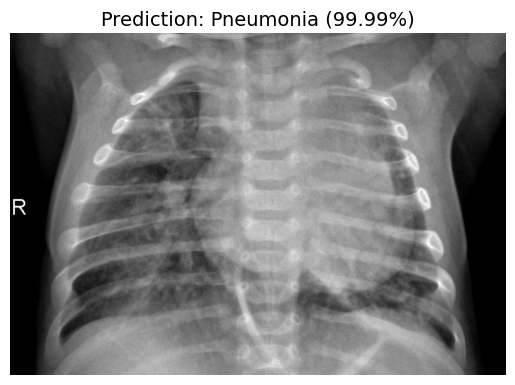

🩻 Prediction: Pneumonia
🔵 Normal: 0.01%
🔴 Pneumonia: 99.99%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0001-0001.jpeg


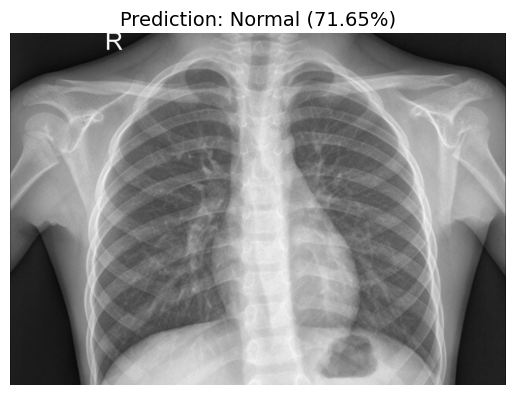

🩻 Prediction: Normal
🔵 Normal: 71.65%
🔴 Pneumonia: 28.35%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person1637_virus_2834.jpeg


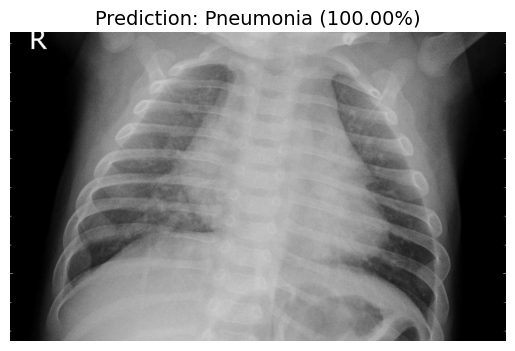

🩻 Prediction: Pneumonia
🔵 Normal: 0.00%
🔴 Pneumonia: 100.00%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0051-0001.jpeg


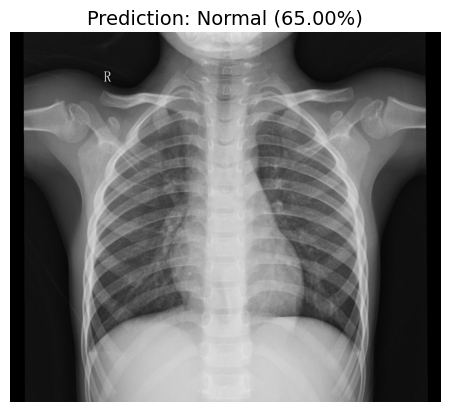

🩻 Prediction: Normal
🔵 Normal: 65.00%
🔴 Pneumonia: 35.00%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0135-0001.jpeg


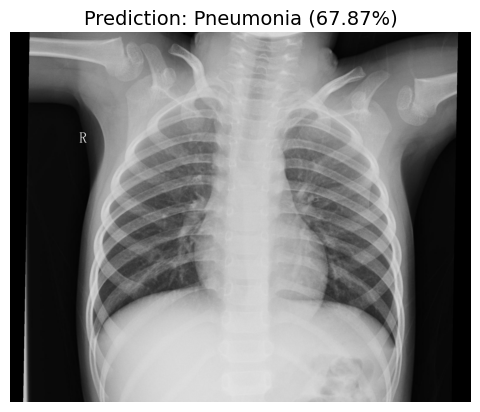

🩻 Prediction: Pneumonia
🔵 Normal: 32.13%
🔴 Pneumonia: 67.87%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person16_virus_47.jpeg


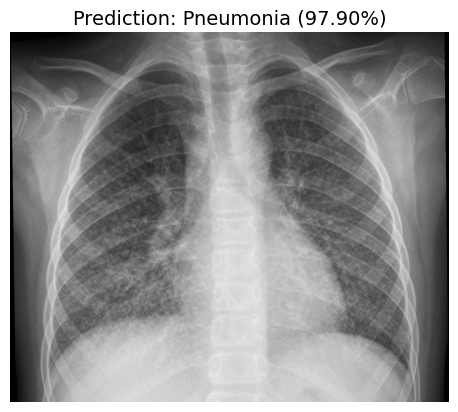

🩻 Prediction: Pneumonia
🔵 Normal: 2.10%
🔴 Pneumonia: 97.90%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0349-0001.jpeg


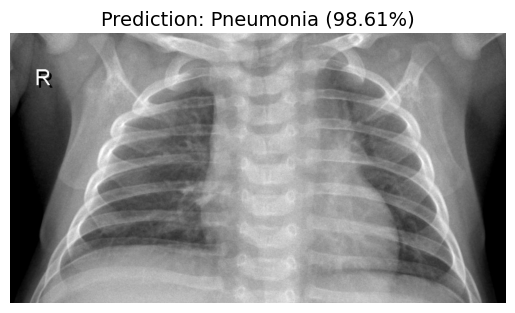

🩻 Prediction: Pneumonia
🔵 Normal: 1.39%
🔴 Pneumonia: 98.61%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0381-0001.jpeg


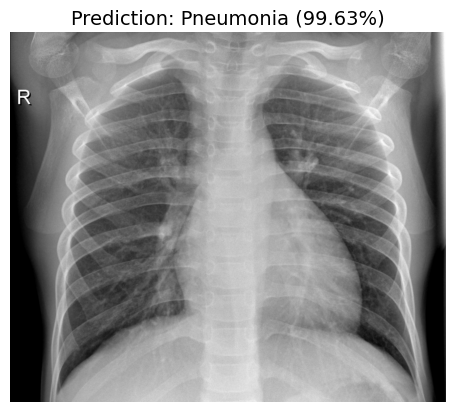

🩻 Prediction: Pneumonia
🔵 Normal: 0.37%
🔴 Pneumonia: 99.63%
--------------------------------------------------
📂 Testing image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person130_bacteria_628.jpeg


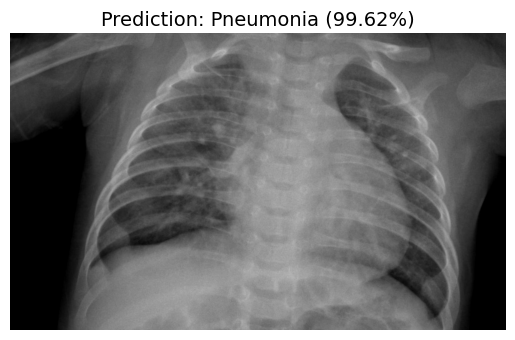

🩻 Prediction: Pneumonia
🔵 Normal: 0.38%
🔴 Pneumonia: 99.62%
--------------------------------------------------


In [ ]:
# List of your 6 test images (Normal & Pneumonia alternates)
image_paths = [
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person100_bacteria_475.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "IM-0001-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person1637_virus_2834.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0051-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0135-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person16_virus_47.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0349-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "NORMAL", "NORMAL2-IM-0381-0001.jpeg"),
    os.path.join(DATASET_DIR, "test", "PNEUMONIA", "person130_bacteria_628.jpeg")
]

# Loop through and visualize
for img_path in image_paths:
    print(f"📂 Testing image: {img_path}")
    predict_and_visualize(img_path)
    print("-" * 50)